In [28]:
#   Librerias
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


#   Cargar los datos
BASE_DIR = Path.cwd()
ruta_archivo = BASE_DIR.parent / 'Datos' / 'diagnostico_limpio.csv'
df_pivot = pd.read_csv(ruta_archivo)

df_pivot.head()

,pais,año,apertura_comercial,crecimiento_pib,desempleo,inflacion,pib_per_capita
0,BRA,2018,28.876203,1.783667,12.329,3.664850,8722.335300
1,BRA,2019,28.890258,1.220778,11.936,3.732976,8771.439504
2,BRA,2020,32.302079,-3.276759,13.697,3.211768,8435.010462
3,BRA,2021,37.656331,4.762604,13.158,8.301660,8799.228446
4,BRA,2022,38.816066,3.016694,9.231,9.280106,9032.083777


In [29]:
#   Configuración de países
PAISES = {
    'BRA': {
        'nombre': 'Brasil',
        'color_pib': '#1a6fa8',
        'color_inf': '#c0392b',
        'color_des': '#f39c12'
    },

    'CHL': {
        'nombre': 'Chile',
        'color_pib': '#16a085',
        'color_inf': '#8e44ad',
        'color_des': '#e67e22'
    },

    'COL': {
        'nombre': 'Colombia',
        'color_pib': '#f1c40f',
        'color_inf': '#e74c3c',
        'color_des': '#3498db'
    },

    'URY': {
        'nombre': 'Uruguay',
        'color_pib': '#9b59b6',
        'color_inf': '#2ecc71',
        'color_des': '#d35400'
    }
}

In [ ]:
#   Configuración de gráficos
plt.rcParams.update({
    'figure.facecolor': '#1e2235',
    'axes.facecolor':   '#141826',
    'axes.edgecolor':   '#2e3450',
    'axes.labelcolor':  '#8892a4',
    'axes.titlecolor':  '#e8eaf6',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'grid.color':       '#2e3450',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'legend.facecolor': '#1e2235',
    'legend.edgecolor': '#2e3450',
    'legend.labelcolor':'#e8eaf6',
    'text.color':       '#e8eaf6',
})

In [ ]:
#   Gráfico diagnóstico
def graficar_pais(nombre, df):
    cfg = PAISES[nombre]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f'Análisis Macroeconómico — {cfg["nombre"]}',
        fontsize=15,
        fontweight='bold'
    )


    # Gráfico: PIB per cápita
    ax = axes[0, 0]
    ax.plot(
        df['año'],
        df['pib_per_capita'],
        marker='o',
        lw=2,
        color=cfg['color_pib']
    )
    ax.set_title('PIB per cápita')
    ax.set_ylabel('USD constantes')
    ax.grid(True)


    # Gráfico: Crecimiento PIB
    ax = axes[0, 1]
    colores = [
        '#2ecc71' if x >= 0 else '#e74c3c'
        for x in df['crecimiento_pib']
    ]
    ax.bar(
        df['año'],
        df['crecimiento_pib'],
        color=colores,
        alpha=0.8
    )
    ax.axhline(0, color='white', lw=1)
    ax.set_title('Crecimiento PIB (%)')
    ax.set_ylabel('%')
    ax.grid(True)


    # Gráfico: Inflación
    ax = axes[1, 0]
    ax.plot(
        df['año'],
        df['inflacion'],
        marker='D',
        lw=2,
        color=cfg['color_inf']
    )
    ax.fill_between(
        df['año'],
        df['inflacion'],
        alpha=0.2,
        color=cfg['color_inf']
    )
    ax.set_title('Inflación (%)')
    ax.set_ylabel('%')
    ax.grid(True)

  
    # Gráfico: Desempleo
    ax = axes[1, 1]
    ax.plot(
        df['año'],
        df['desempleo'],
        marker='s',
        lw=2,
        color=cfg['color_des']
    )
    ax.fill_between(
        df['año'],
        df['desempleo'],
        alpha=0.2,
        color=cfg['color_des']
    )
    ax.set_title('Desempleo (%)')
    ax.set_ylabel('%')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

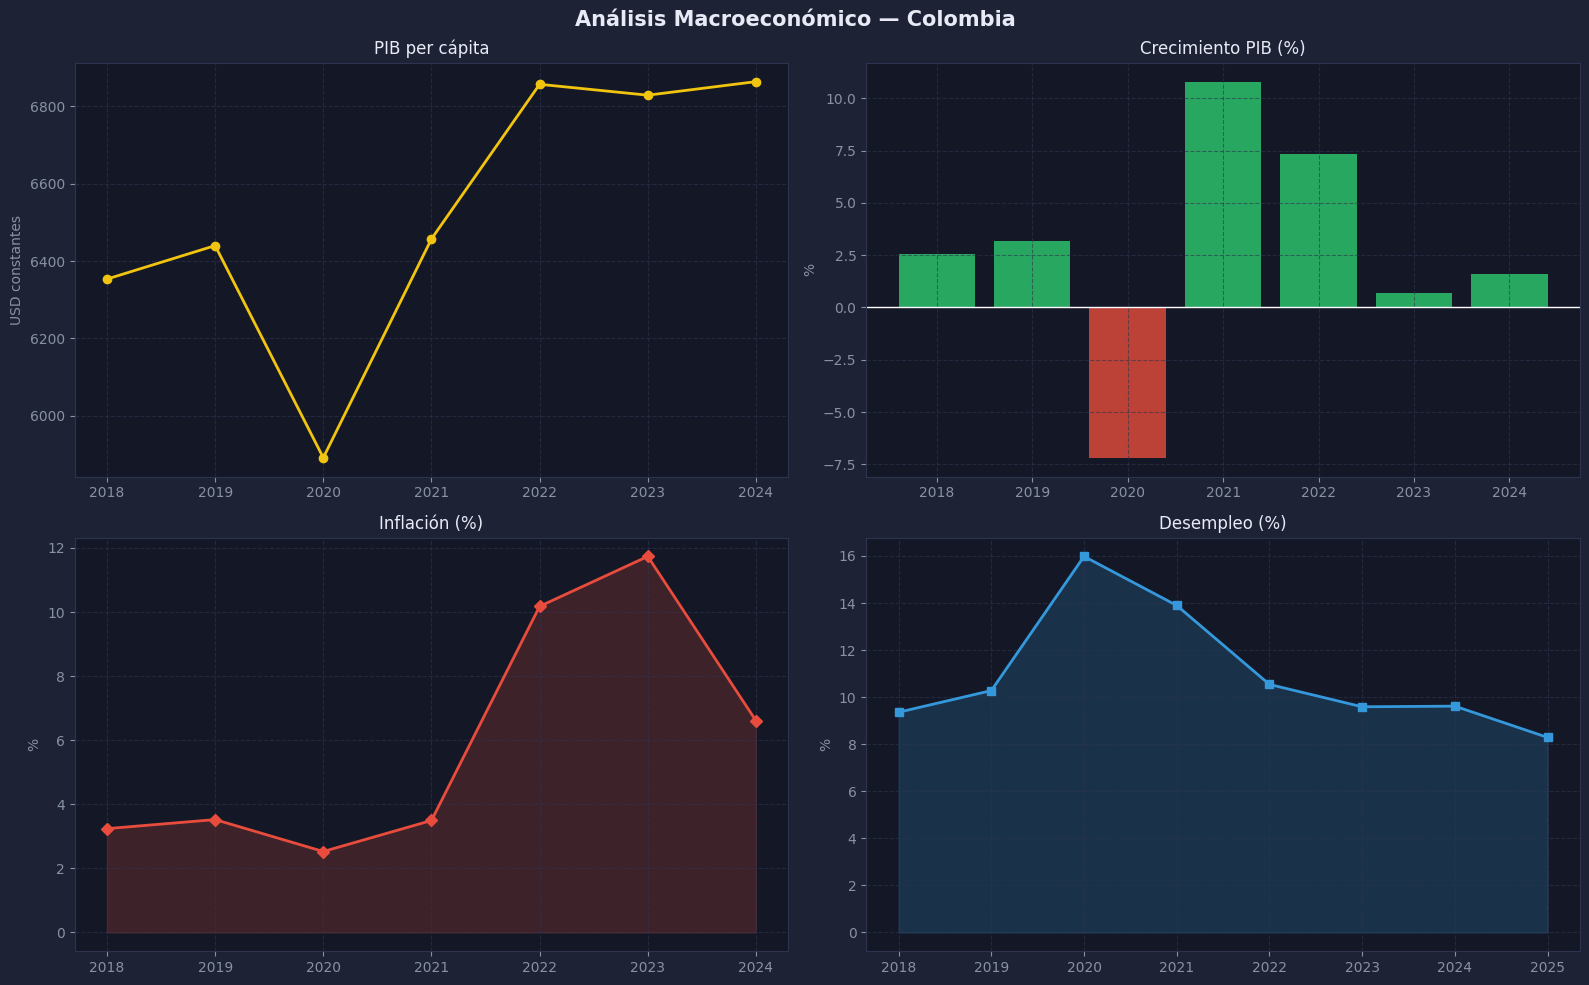

In [30]:
#   Colombia
df_col = df_pivot[df_pivot['pais'] == 'COL']
graficar_pais('COL', df_col)

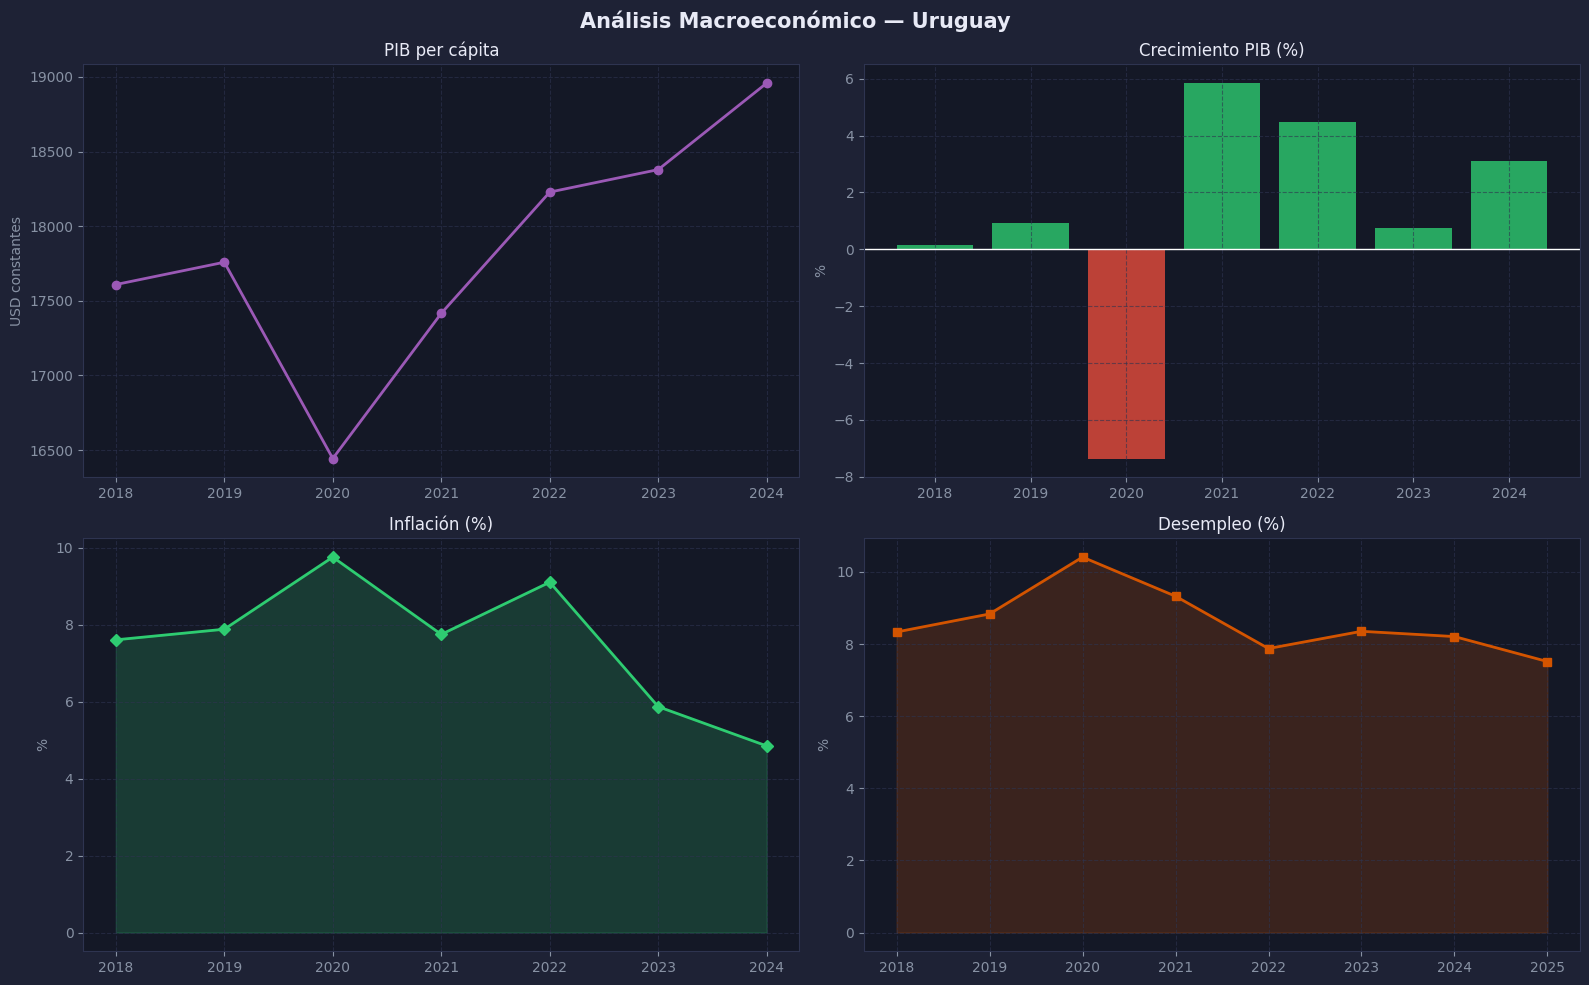

In [ ]:
#   Uruguay
df_ury = df_pivot[df_pivot['pais'] == 'URY']
graficar_pais('URY', df_ury)

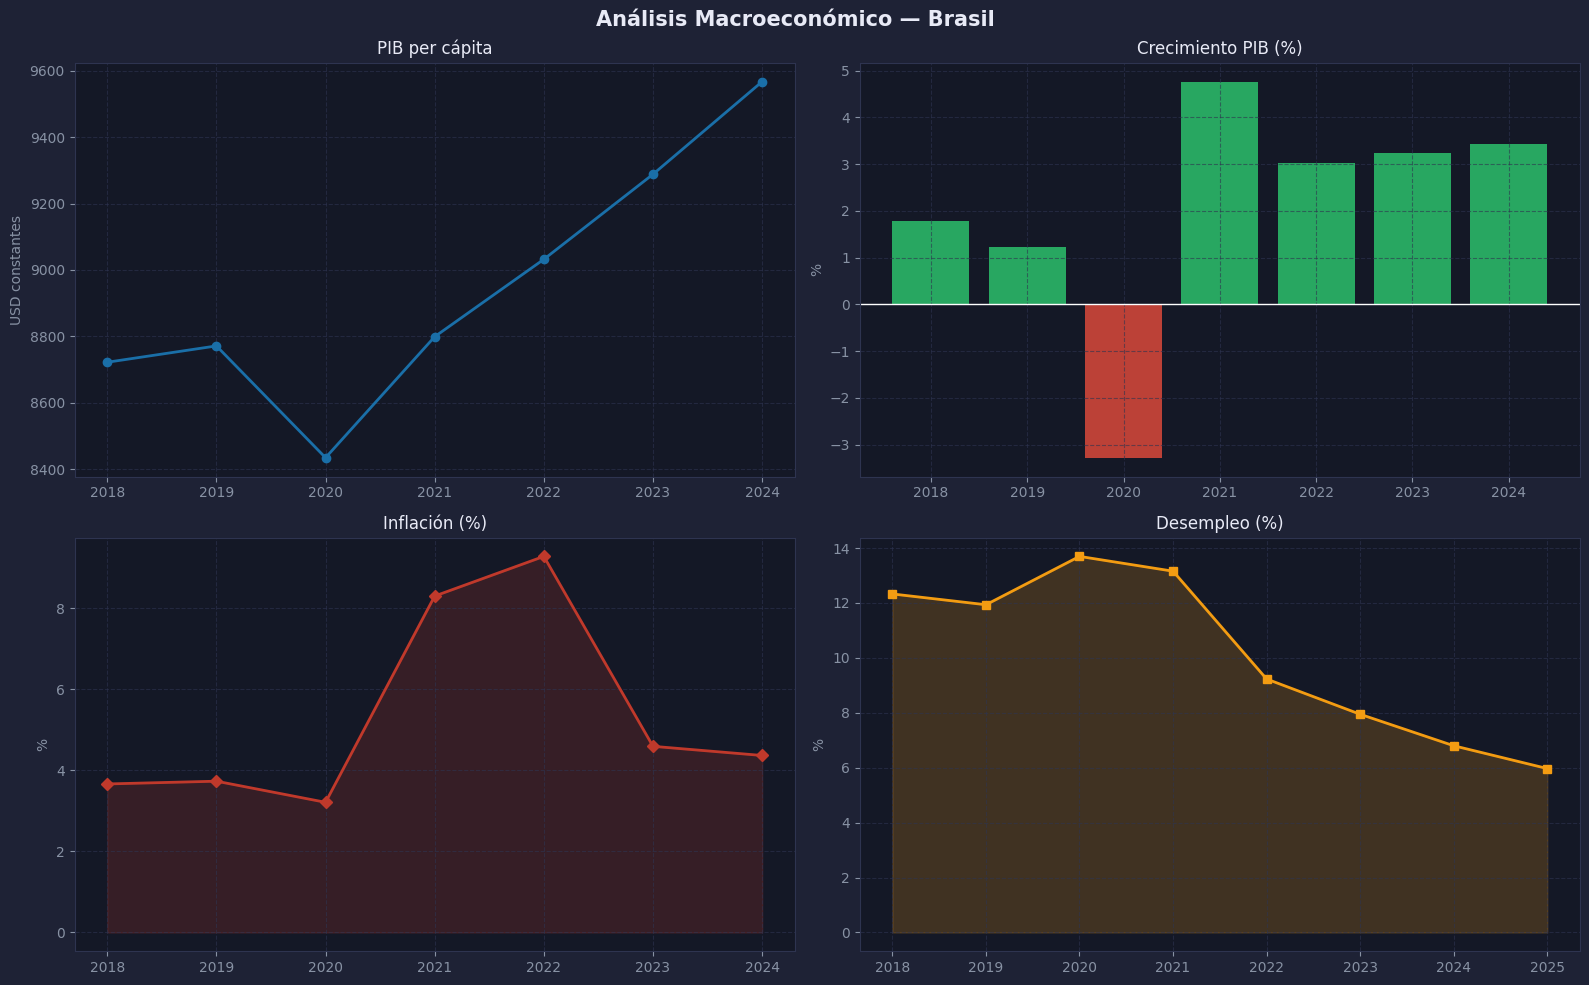

In [32]:
#   Brasil
df_bra = df_pivot[df_pivot['pais'] == 'BRA']
graficar_pais('BRA', df_bra)

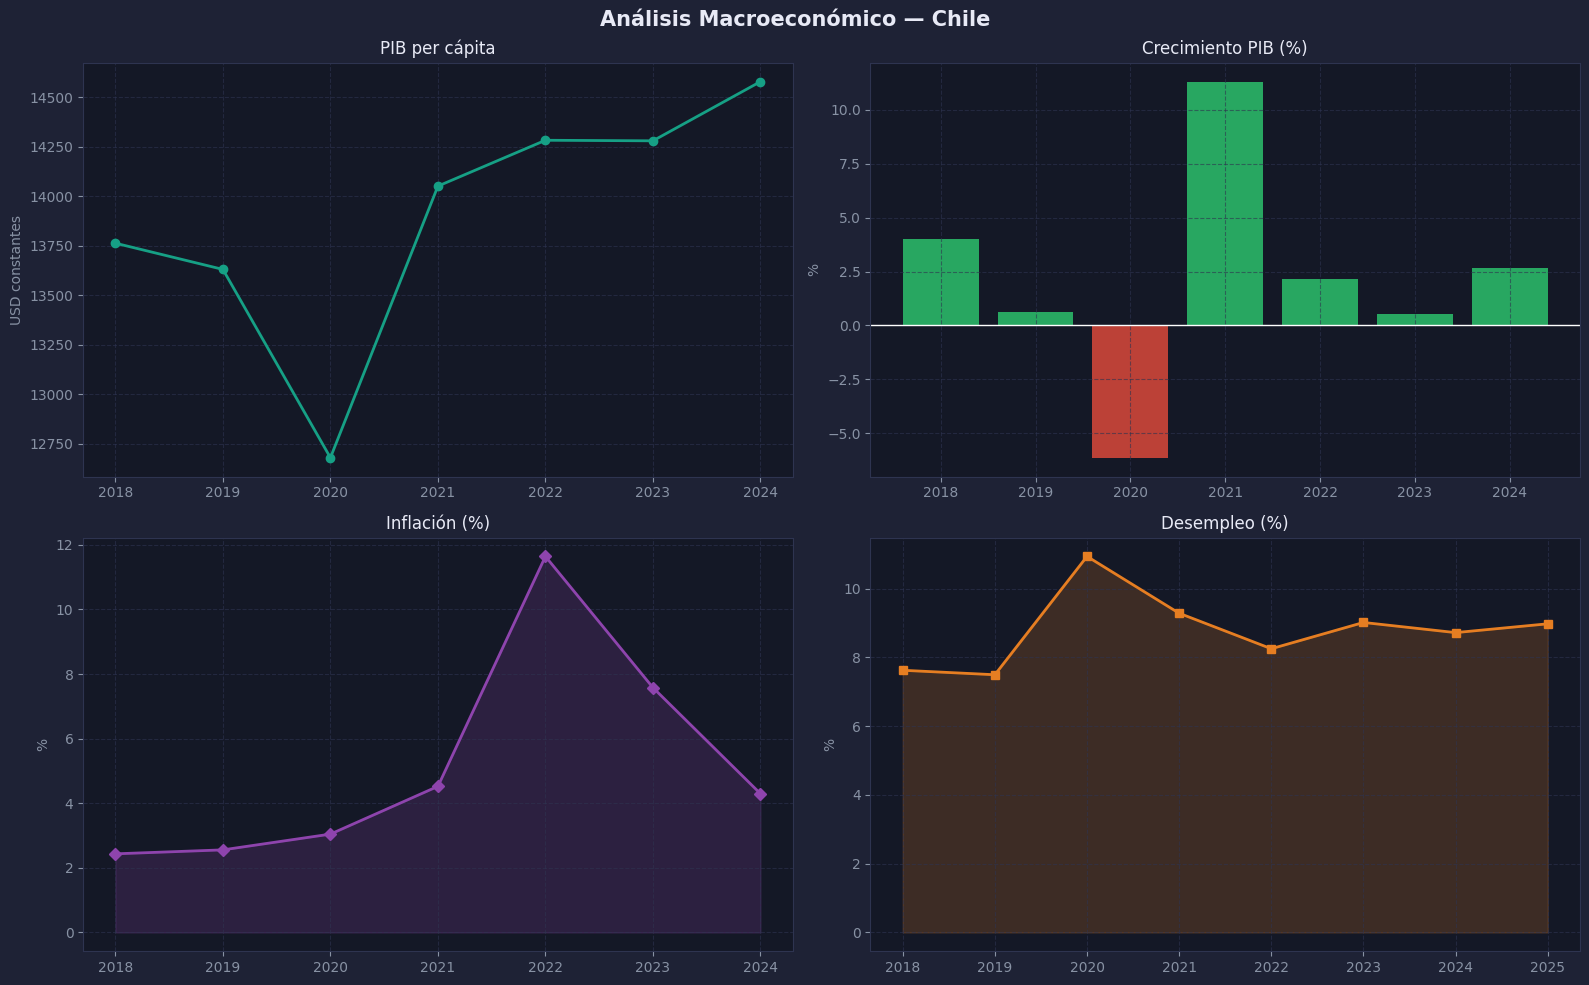

In [33]:
#   Chile
df_chl = df_pivot[df_pivot['pais'] == 'CHL']
graficar_pais('CHL', df_chl)

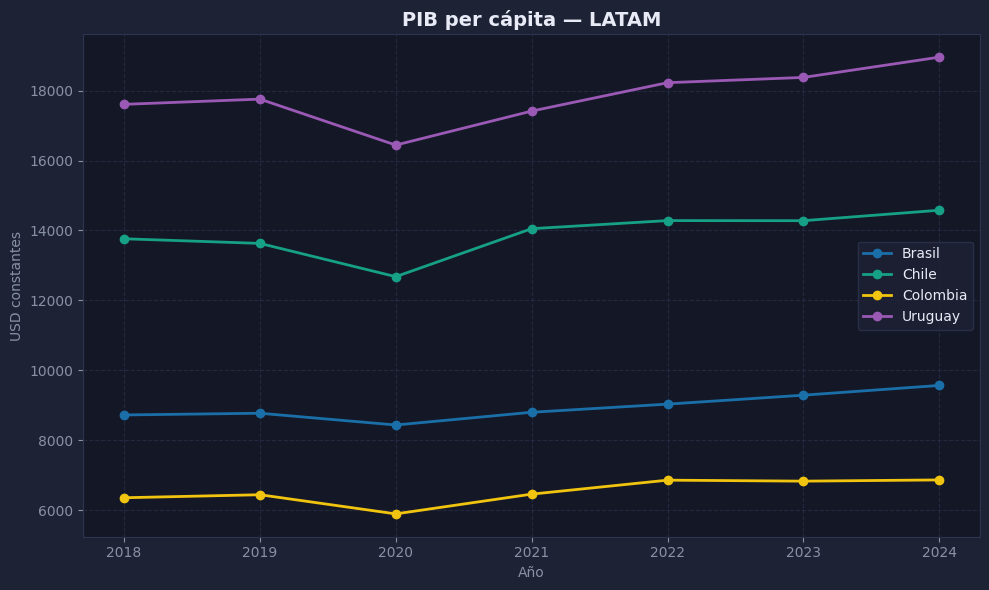

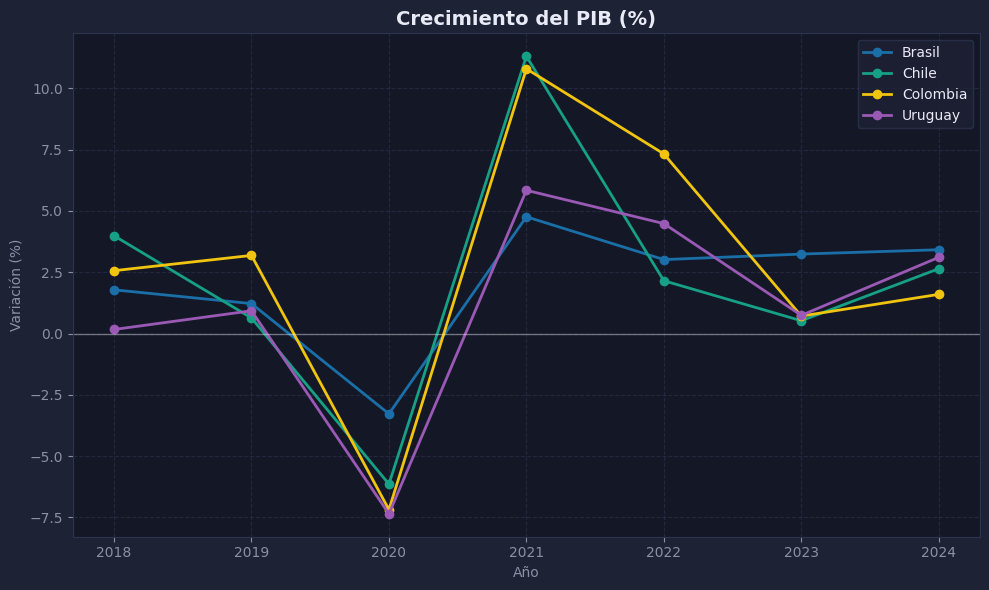

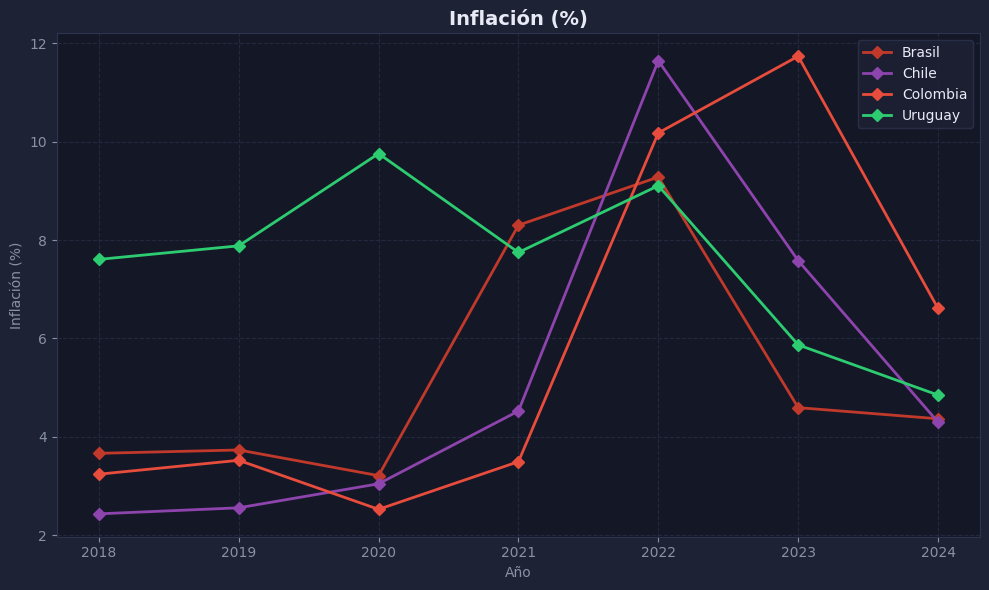

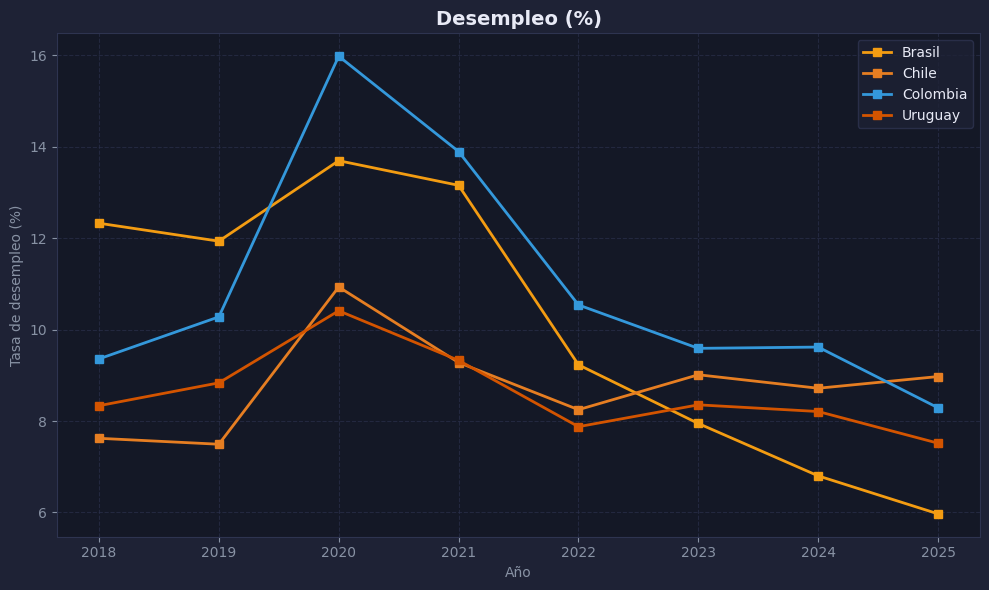

In [ ]:
#   Comparación entre países

# PIB per cápita
plt.figure(figsize=(10, 6))

for pais, cfg in PAISES.items():

    df = df_pivot[df_pivot['pais'] == pais]

    plt.plot(
        df['año'],
        df['pib_per_capita'],
        marker='o',
        lw=2,
        label=cfg['nombre'],
        color=cfg['color_pib']
    )

plt.title(
    'PIB per cápita — LATAM',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Año')
plt.ylabel('USD constantes')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Crecimiento económico
plt.figure(figsize=(10, 6))

for pais, cfg in PAISES.items():

    df = df_pivot[df_pivot['pais'] == pais]

    plt.plot(
        df['año'],
        df['crecimiento_pib'],
        marker='o',
        lw=2,
        label=cfg['nombre'],
        color=cfg['color_pib']
    )

plt.axhline(
    0,
    color='#ffffff60',
    lw=1
)

plt.title(
    'Crecimiento del PIB (%)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Año')
plt.ylabel('Variación (%)')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Inflación
plt.figure(figsize=(10, 6))

for pais, cfg in PAISES.items():

    df = df_pivot[df_pivot['pais'] == pais]

    plt.plot(
        df['año'],
        df['inflacion'],
        marker='D',
        lw=2,
        label=cfg['nombre'],
        color=cfg['color_inf']
    )

plt.title(
    'Inflación (%)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Año')
plt.ylabel('Inflación (%)')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Desempleo
plt.figure(figsize=(10, 6))

for pais, cfg in PAISES.items():

    df = df_pivot[df_pivot['pais'] == pais]

    plt.plot(
        df['año'],
        df['desempleo'],
        marker='s',
        lw=2,
        label=cfg['nombre'],
        color=cfg['color_des']
    )

plt.title(
    'Desempleo (%)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Año')
plt.ylabel('Tasa de desempleo (%)')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

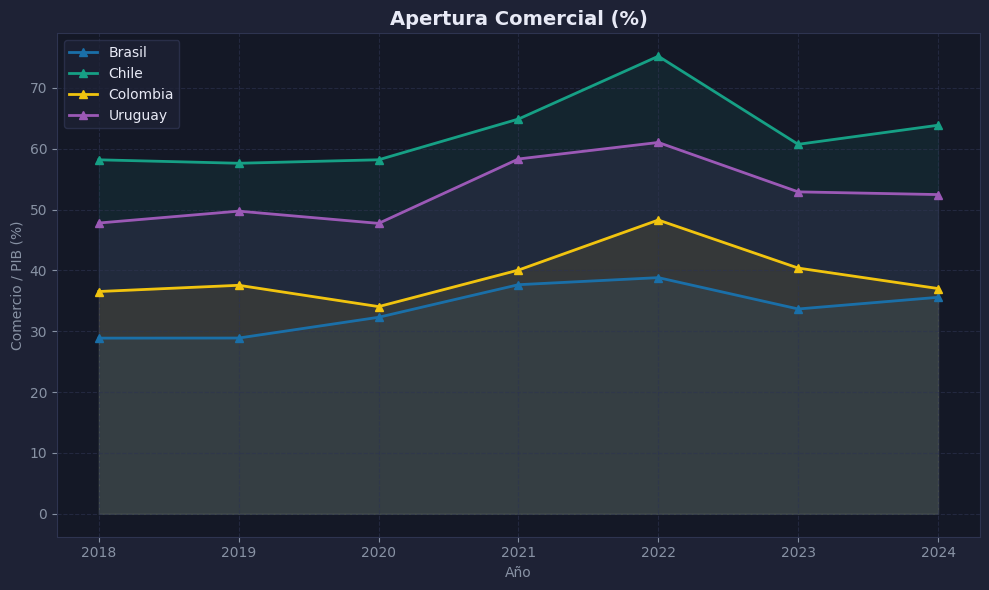

In [ ]:
# Apertura comercial
plt.figure(figsize=(10, 6))

for pais, cfg in PAISES.items():

    df = df_pivot[df_pivot['pais'] == pais]

    plt.plot(
        df['año'],
        df['apertura_comercial'],
        marker='^',
        lw=2,
        label=cfg['nombre'],
        color=cfg['color_pib']
    )

    plt.fill_between(
        df['año'],
        df['apertura_comercial'],
        alpha=0.10,
        color=cfg['color_pib']
    )

plt.title(
    'Apertura Comercial (%)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Año')
plt.ylabel('Comercio / PIB (%)')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()